### Задача

1. Файл donations.csv, TargetB (пожертвовал или нет), TargetD (сумма пожертвования или пропуск). В рамках первой части построить регрессионную модель (только по людям, который жертвовали)  

2. Валидационная выборка и ее визуализация

3. Предобработка данных

4. Отбор важных переменных и лучшей модели BackwardOLS с помощью CV

5. Распределение константы смещения с бутстреппингом.
Оценка OOB ошибки MSE, а также ее соотношение с CV-ошибкой и ошибкой на valid-выборке.

6. MLP (tanh) + HalvingRandomSearchCV.

In [24]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MaxAbsScaler, StandardScaler
from sklearn.experimental import enable_halving_search_cv # пришлось добавить, чтобы заработал HRSCV, так сказал vscode
from sklearn.model_selection import HalvingRandomSearchCV, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error

from category_encoders import TargetEncoder

import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Файл donations.csv, TargetB (пожертвовал или нет), TargetD (сумма пожертвования или пропуск). В рамках первой части построить регрессионную модель (только по людям, который жертвовали)  

In [25]:
start_data = pd.read_csv("donations.csv", index_col='ID')
start_data.head()

,TargetB,TargetD,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,...,PromCntCardAll,StatusCat96NK,StatusCatStarAll,DemCluster,DemAge,DemGender,DemHomeOwner,DemMedHomeValue,DemPctVeterans,DemMedIncome
ID,,,,,,,,,,,,,,,,,,,,,
14974,0,NaN,2,4,1,3,17.0,13.50,9.25,17.00,...,13,A,0,0,NaN,F,U,0,0,NaN
6294,0,NaN,1,8,0,3,20.0,20.00,15.88,NaN,...,24,A,0,23,67.0,F,U,186800,85,NaN
46110,1,4.0,6,41,3,20,6.0,5.17,3.73,5.00,...,22,S,1,0,NaN,M,U,87600,36,38750.0
185937,1,10.0,3,12,3,8,10.0,8.67,8.50,8.67,...,16,E,1,0,NaN,M,U,139200,27,38942.0
29637,0,NaN,1,1,1,1,20.0,20.00,20.00,20.00,...,6,F,0,35,53.0,M,U,168100,37,71509.0


In [26]:
data = start_data[start_data.TargetB==1].drop(columns='TargetB')

X = data.drop(columns='TargetD')
y_D = data.TargetD

#### 2. Валидационная выборка и ее визуализация

Покажем распределение TargetD. <br> 
Увидим, что отклик непрерывный и распределен неравномерно. <br>
Для дискретизации разобьем отклик на 6 квантилей.<br>

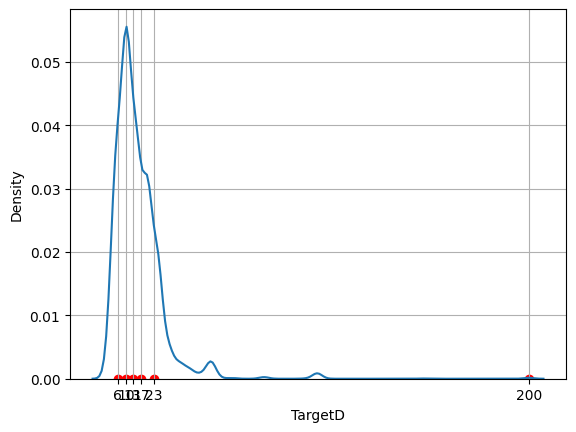

In [27]:
sns.kdeplot(y_D)
q = 6
right_tresholds = np.quantile(y_D, q=np.linspace(1/q, 1, q))
plt.scatter(right_tresholds, [0]*q, color='r')
plt.xticks(right_tresholds)
plt.grid(True)

Добавим метку квантиля для каждого наблюдения.

In [28]:
X['quantile'] = pd.qcut(data.TargetD, q=q, labels=range(q))

Разделим выборку со стратицикацией по размеченным данным.

In [29]:
X_train, X_val, y_D_train, y_D_val = train_test_split(X, y_D,
                                                      test_size=0.3,
                                                      stratify=X['quantile'],
                                                      random_state=7
                                                      )

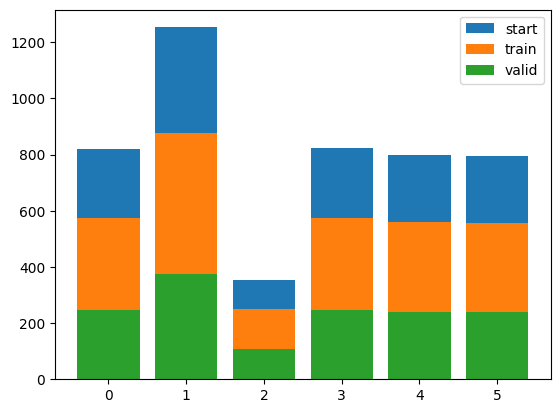

In [30]:
plt.bar(range(q), X['quantile'].value_counts().sort_index(), label='start')
plt.bar(range(q), X_train['quantile'].value_counts().sort_index(), label='train')
plt.bar(range(q), X_val['quantile'].value_counts().sort_index(), label='valid')
plt.legend()
plt.xticks(range(q))
plt.show()

Изобразим все выборки в kde-апроксимации и с помощью гистограммы.

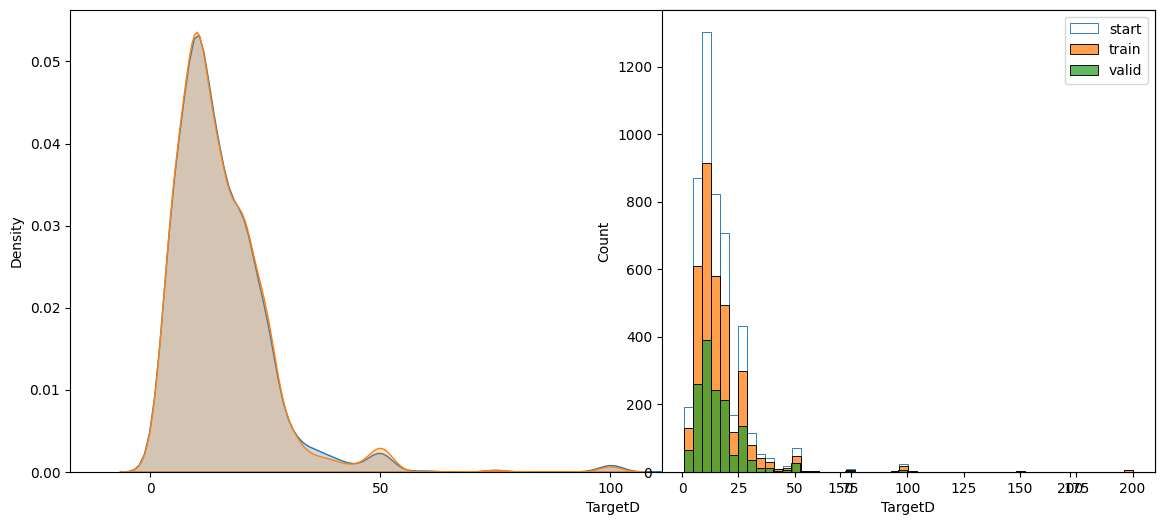

In [31]:
plt.figure(figsize=(14, 6))

sns.kdeplot(y_D_train, fill=1, label='train')
sns.kdeplot(y_D_val, fill=1, label='valid')
plt.legend()

plt.subplot(1, 2, 2)

sns.histplot(y_D, bins=50, label='start', fill=0)
sns.histplot(y_D_train, bins=50, label='train')
sns.histplot(y_D_val, bins=25, label='valid')
plt.legend()
plt.show()

plt.show()

Видим, что стратификация сработала довольно удачно.

Удалим столбец quantile, потому что его нельзя использовать при обучении

In [32]:
X.drop(columns=['quantile'], inplace=True)
X_train.drop(columns=['quantile'], inplace=True)
X_val.drop(columns=['quantile'], inplace=True)

#### 3. Предобработка данных

В ервую очередь заполним пропуски в данных (c помощью SimpleImputer) и преобразуем категориальные признаки (c помощью TargetEncoder)

In [33]:
def imputing_and_encoding(X, y):
    X_col = X.select_dtypes([int, float])
    X_cat = X.select_dtypes([object])

    nans = X_col.isna().sum()
    nans = nans[nans>0]
    missing_c = nans.index

    col_c = X_col.columns
    
    imputer = SimpleImputer(strategy='median', add_indicator=True)
    X_col_imputed = imputer.fit_transform(X_col)

    X_col = pd.DataFrame(
        X_col_imputed,
        columns=list(col_c) + [f'{col}_imputed' for col in missing_c],
        index=X.index
    )

    X_cat = X.select_dtypes([object])
    cat_c = X_cat.columns

    encoder = TargetEncoder(cols=cat_c)
    X_cat = encoder.fit_transform(X_cat, y)

    return pd.concat([X_col, X_cat], axis=1)

посомтрим на получившиеся распределения данных

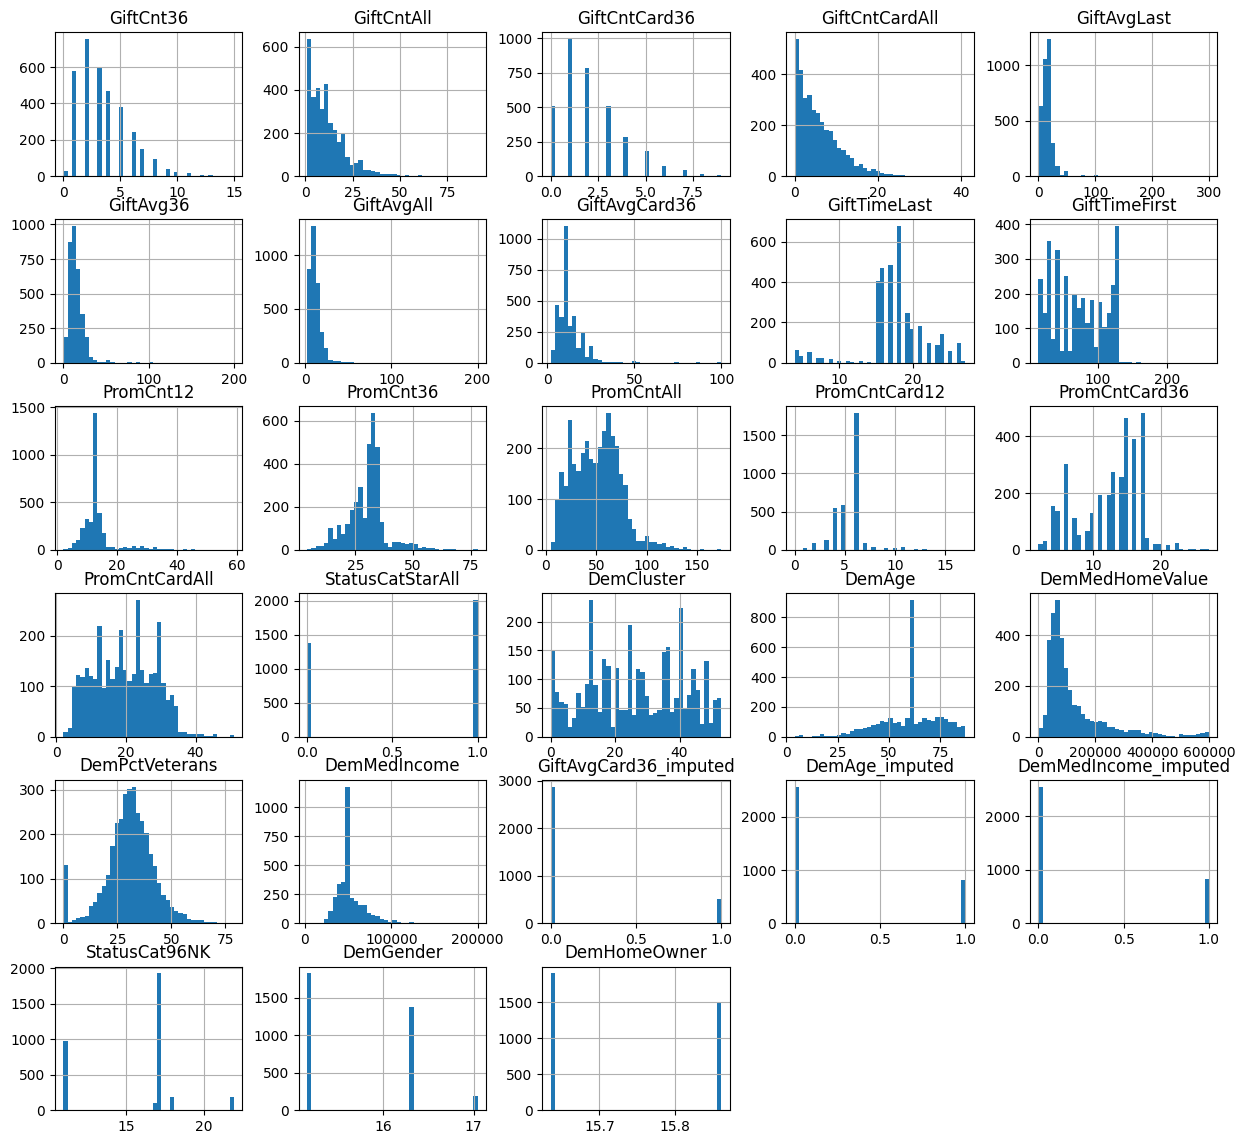

In [34]:
imputing_and_encoding(X_train, y_D_train).hist(bins=40, figsize=(15, 14))
plt.show()

видим, что есть признаки, которые распределены около-нормально, около-равномерно, а также признаки с тяжелым правым хвостом.

In [35]:
def preprocessing(X, y):
    X = imputing_and_encoding(X, y)

    # тяжелый правый хвост (log + StandartScaler)
    columns1 = ['GiftCnt36', 'GiftCntAll', 'GiftCntCard36', 'GiftCntCardAll',
                'PromCnt12', 'PromCnt36', 'PromCntAll', 'DemMedHomeValue']
    X[columns1] = np.log(1 + X[columns1])
    scaler = StandardScaler()
    X[columns1] = scaler.fit_transform(X[columns1])

    # около-равномерные 
    columns2 = ['GiftTimeFirst', 'DemCluster']
    scaler = MaxAbsScaler()
    X[columns2] = scaler.fit_transform(X[columns2])

    # около-нормальные
    columns3 = ['GiftAvgLast', 'GiftAvg36', 'GiftAvgAll', 'GiftAvgCard36',
                'GiftTimeLast', 'PromCntCard12', 'PromCntCard36', 
                'PromCntCardAll', 'StatusCat96NK',  
                'DemAge', 'DemGender', 'DemHomeOwner', 'DemPctVeterans', 'DemMedIncome']
    scaler = StandardScaler()
    X[columns3] = scaler.fit_transform(X[columns3])

    return X

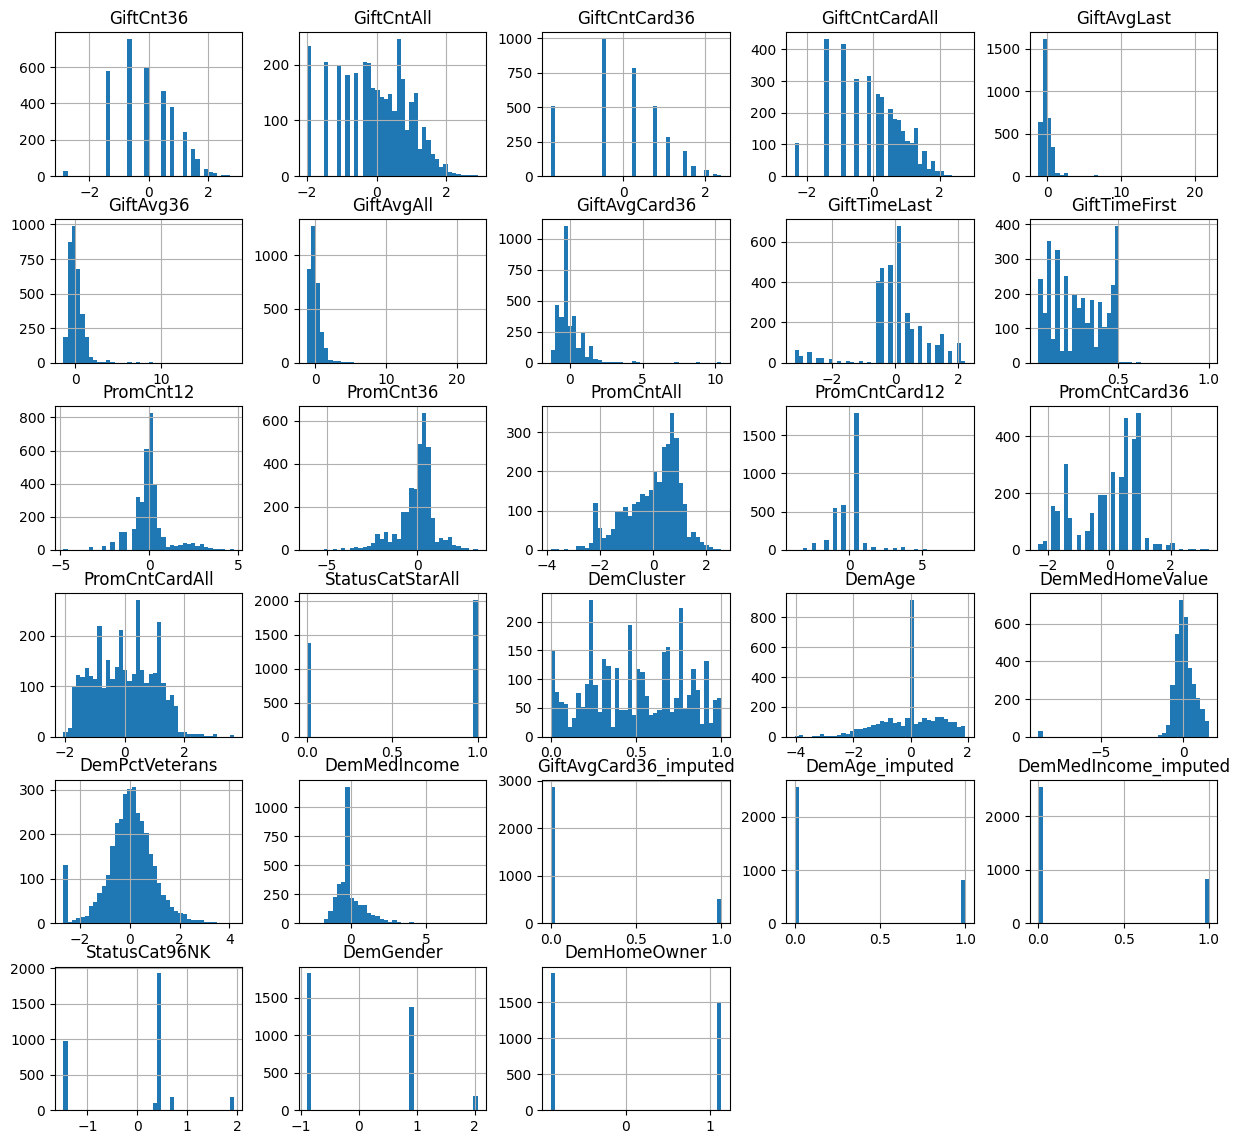

In [36]:
preprocessing(X_train, y_D_train).hist(bins=40, figsize=(15, 14))
plt.show()

Получили более-менее нормализованные признаки и убрали хвосты

In [37]:
X_train = preprocessing(X_train, y_D_train)
X_val = preprocessing(X_val, y_D_val)

#### 4. Отбор важных переменных и лучшей модели BackwardOLS с помощью CV

Для реализации BackwardOLS c CV, воспользуемся RFECV (Recursive feature elimination with cross-validation) 

In [38]:
model = LinearRegression(fit_intercept=True)
selector = RFECV(
    estimator=model,
    cv=5,
    scoring='neg_mean_squared_error'
)

selector.fit(X_train, y_D_train)
None

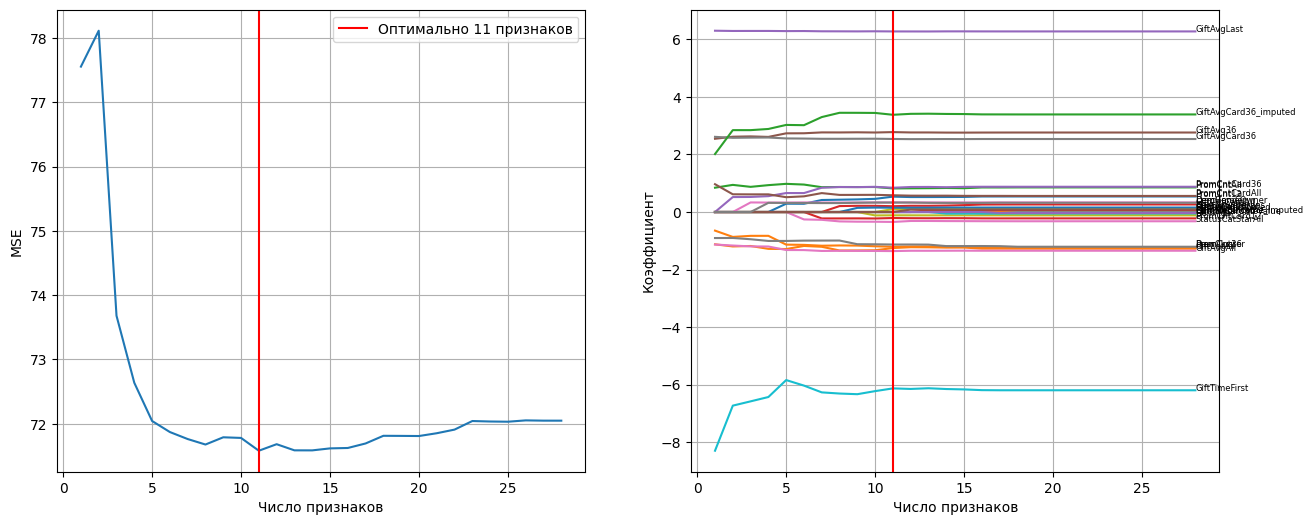

Выбранные признаки: ['GiftCntAll' 'GiftAvgLast' 'GiftAvg36' 'GiftAvgAll' 'GiftAvgCard36'
 'GiftTimeFirst' 'PromCnt36' 'PromCntAll' 'PromCntCardAll' 'DemCluster'
 'GiftAvgCard36_imputed']
MSE при оптимальном числе признаков: 71.58137413258687


In [39]:
mse_scores = -selector.cv_results_['mean_test_score']
num_features = np.arange(1, len(mse_scores) + 1)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(num_features, mse_scores)
plt.axvline(x=selector.n_features_, color='r', label=f'Оптимально {selector.n_features_} признаков')
plt.xlabel('Число признаков')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)

coef_paths = []
for i in range(selector.n_features_in_):
    mask = selector.ranking_ <= i+1
    model = LinearRegression(fit_intercept=True)
    model.fit(X_train.iloc[:, mask], y_D_train)
    coefs = np.zeros(selector.n_features_in_)
    coefs[mask] = model.coef_
    coef_paths.append(coefs)

coef_paths = np.array(coef_paths)

for i, name in enumerate(X_train.columns):
    line = plt.plot(num_features, coef_paths[:, i])
    plt.text(num_features[-1], coef_paths[-1, i], name, fontsize=6)

plt.axvline(x=selector.n_features_, color='r')
plt.xlabel('Число признаков')
plt.ylabel('Коэффициент')
plt.grid(True)
plt.show()

print("Выбранные признаки:", np.array(X_train.columns)[selector.support_])
print("MSE при оптимальном числе признаков:", mse_scores[selector.n_features_ - 1])


посмотрим MSE на виладационной выборке

In [40]:
optimal_n = selector.n_features_
optimal_mask = selector.ranking_ == 1

model.fit(X_train.iloc[:, optimal_mask], y_D_train)

y_D_val_pred = model.predict(X_val.iloc[:, optimal_mask])
mse_D_val = mean_squared_error(y_D_val, y_D_val_pred)
print('MSE на валидационной выборке:', mse_D_val)

MSE на валидационной выборке: 79.81464777483247


#### 5. Распределение константы смещения с бутстреппингом.
#### Оценка OOB ошибки MSE, а также ее соотношение с CV-ошибкой и ошибкой на valid-выборке.

будем логировать все свободные члены и oob ошибки MSE. 

In [41]:
intercept_history = []
oob_history = []

for i in range(100):
    model = LinearRegression(fit_intercept=True)

    indexes = np.random.randint(0, X_train.shape[0], size=(int(X_train.shape[0]*0.25)))
    bootstrap_Xtrain_i = X_train.iloc[indexes]
    bootstrap_ytrain_i = y_D_train.iloc[indexes]

    model.fit(bootstrap_Xtrain_i.iloc[:, optimal_mask], bootstrap_ytrain_i)
    intercept_history.append(model.intercept_)

    oob_indexes = list(set(range(X_train.shape[0])) - set(indexes))
    oob_X_train = X_train.iloc[oob_indexes]
    oob_y_train = y_D_train.iloc[oob_indexes]

    y_train_pred = model.predict(oob_X_train.iloc[:, optimal_mask])
    oob_mse = mean_squared_error(oob_y_train, y_train_pred)
    oob_history.append(oob_mse)

history1 = np.array(intercept_history)
history2 = np.array(oob_history)

проиллюстрируем распределения и отметим на них среднее и 95% интервал.

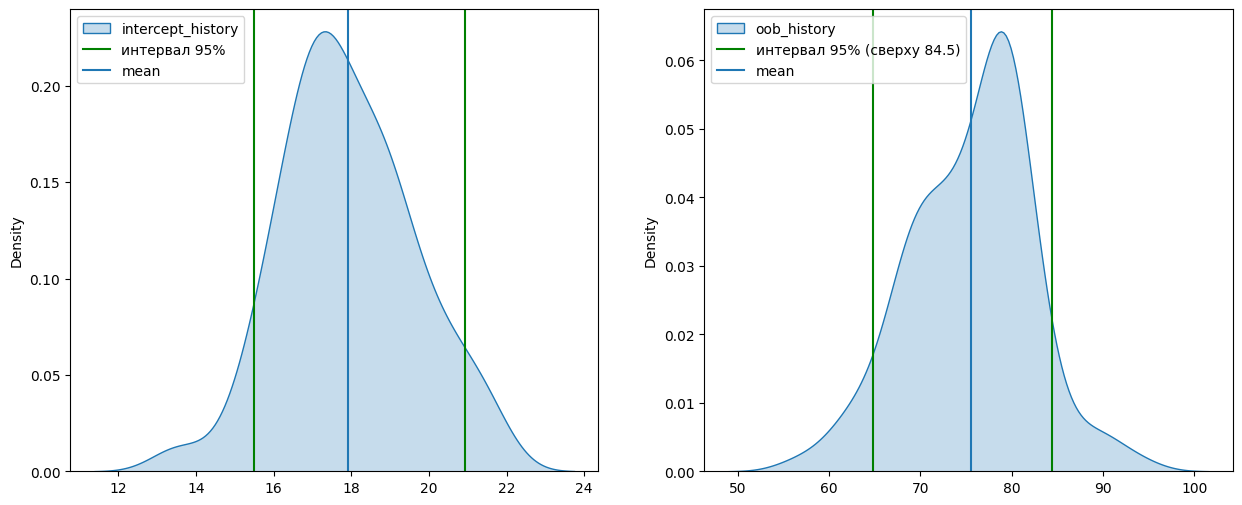

Среднее значение константы смещения: 17.9079373185824
Среднее значение oob: 75.56905947074284


In [42]:

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)

sns.kdeplot(history1, fill=1, label='intercept_history')
plt.axvline(np.quantile(history1, q=0.05), c='g')
plt.axvline(np.quantile(history1, q=0.95), label='интервал 95%', c='g')
plt.axvline(history1.mean(), label='mean')
plt.legend()

plt.subplot(1, 2, 2)

sns.kdeplot(history2, fill=1, label='oob_history')
plt.axvline(np.quantile(history2, q=0.05), c='g')
plt.axvline(np.quantile(history2, q=0.95), label=f'интервал 95% (cверху {np.quantile(history2, q=0.95):.1f})', c='g')
plt.axvline(history2.mean(), label='mean')

plt.legend()
plt.show()

print('Среднее значение константы смещения:', history1.mean())

print('Среднее значение oob:', history2.mean())


Полученные результаты показывают, что модель линейной регрессии работает стабильно: ошибки на кросс-валидации (71), OOB-выборке и валидации (79) близки, что исключает переобучение. Интервал OOB-MSE подтверждает устойчивость предсказаний.

#### 6. MLP (tanh) + HalvingRandomSearchCV.

попробуем нейронку из одного, двух и трех слоев, разными коэфициентами регуляризации и оптимизатором adam.

отключим также предупреждения для чистого вывода. (Вылезают предупреждения о том, что алгоритм не успел сойтись за 200 итераций - столько их по умолчанию)

In [45]:
import warnings
warnings.filterwarnings('ignore')

In [99]:
hard_model = MLPRegressor(activation='tanh', solver='adam')
params = {
    'hidden_layer_sizes': [(32,), (64,), (128,), (128, 64), (128, 64, 32)],
    'alpha': [0.0001, 0.001, 0.01, 0.1]
}
hrscv = HalvingRandomSearchCV(estimator=hard_model, param_distributions=params, cv=5, scoring='neg_mean_squared_error', random_state=42)
hrscv.fit(X_train, y_D_train)

best_hard_model = hrscv.best_estimator_

y_D_val_pred = best_hard_model.predict(X_val)

print(f"MSE на валидационной выборке: {mean_squared_error(y_D_val, y_D_val_pred)}")

MSE на валидационной выборке: 71.97428460051951


Самая лучшая комбинация гиперпараметров:
param_hidden_layer_sizes    (128, 64, 32)
param_alpha                          0.01
mse                             60.661433
Name: 25, dtype: object


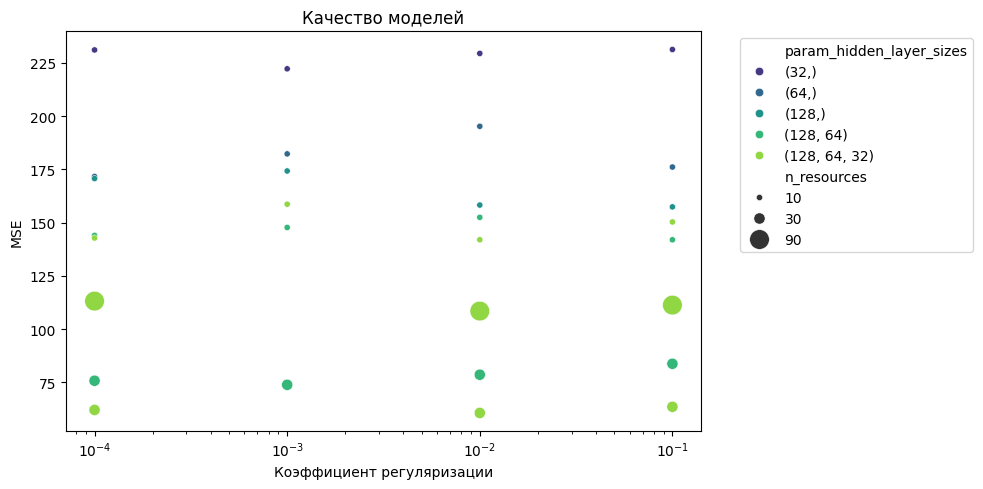

In [100]:
df_results = pd.DataFrame(hrscv.cv_results_)
df_results['mse'] = -df_results['mean_test_score']

print('Самая лучшая комбинация гиперпараметров:')
print(df_results.loc[np.argmin(df_results.mse)][['param_hidden_layer_sizes', 'param_alpha', 'mse']])

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_results,
    x='param_alpha',
    y='mse',
    hue='param_hidden_layer_sizes',
    size='n_resources',
    sizes=(20, 200),
    palette='viridis'
)
plt.xscale('log')
plt.title('Качество моделей')
plt.xlabel('Коэффициент регуляризации')
plt.ylabel('MSE')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

сведем модели в сравнительную таблицу

In [101]:
pd.DataFrame({
    'Модель': ['Линейная', 'MLP'],
    'CV MSE': [mse_scores[selector.n_features_ - 1], -hrscv.best_score_],
    'OOB MSE': [history2.mean(), None],
    'Valid MSE': [mse_D_val, mean_squared_error(y_D_val, y_D_val_pred)]
})

,Модель,CV MSE,OOB MSE,Valid MSE
0,Линейная,71.581374,75.569059,79.814648
1,MLP,108.500615,NaN,71.974285


MLP дала более хорошую оценку на валидационной выборке, но недостаточно, чтобы оправдать свою нестабильность, которую видно из плохой CVMSE, тогда как линейная модель показала устойчивые результаты на каждом этапе, хоть и уступающие на последнем этапе оценке (Valid).